<a href="https://colab.research.google.com/github/sap-tarshi-ghosh/Image-Processing-Tutorial/blob/main/code/06_k_mean_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

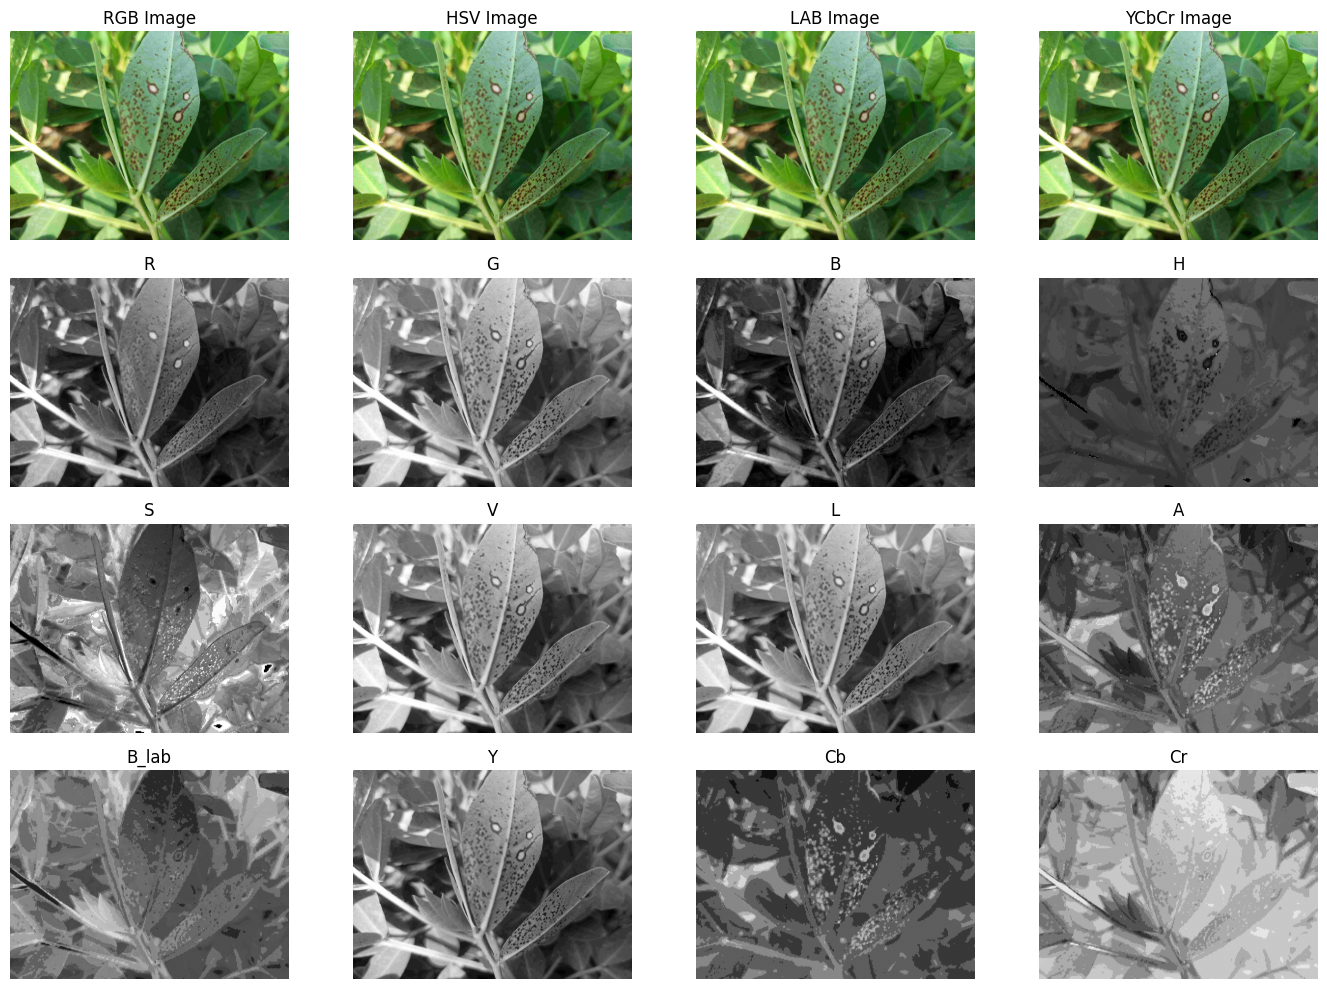

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

folder = "/content/drive/MyDrive/dataset/groundnut_leaf_data"

image_name = os.listdir(folder)[0]
path = os.path.join(folder, image_name)

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#convert to different color spaces
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

#convert them back to RGB for visualization
hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
lab_display = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
ycbcr_display = cv2.cvtColor(ycbcr, cv2.COLOR_YCrCb2RGB)

#split channels
r,g,b = cv2.split(img)
h,s,v = cv2.split(hsv)
l,a,b_lab = cv2.split(lab)
y,cb,cr = cv2.split(ycbcr)

channels = [
("R",r),("G",g),("B",b),
("H",h),("S",s),("V",v),
("L",l),("A",a),("B_lab",b_lab),
("Y",y),("Cb",cb),("Cr",cr)
]

#plotting

plt.figure(figsize=(14,10))

#first row: Color space images
color_images = [
("RGB Image", img),
("HSV Image", hsv_display),
("LAB Image", lab_display),
("YCbCr Image", ycbcr_display)
]

for i,(name,image) in enumerate(color_images):
    plt.subplot(4,4,i+1)
    plt.imshow(image)
    plt.title(name)
    plt.axis("off")

#remaining plots: channels
for i,(name,channel) in enumerate(channels):
    plt.subplot(4,4,i+5)
    plt.imshow(channel,cmap='gray')
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Resize image

In [26]:
import cv2
import os

folder = "/content/drive/MyDrive/dataset/groundnut_leaf_data"

image_name = os.listdir(folder)[3]
path = os.path.join(folder, image_name)

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (512, 512), interpolation=cv2.INTER_AREA)
print("Original shape:", img.shape)
print("Resized shape:", img_resized.shape)

Original shape: (3472, 4624, 3)
Resized shape: (512, 512, 3)


# K means using HSV chromaticity without value

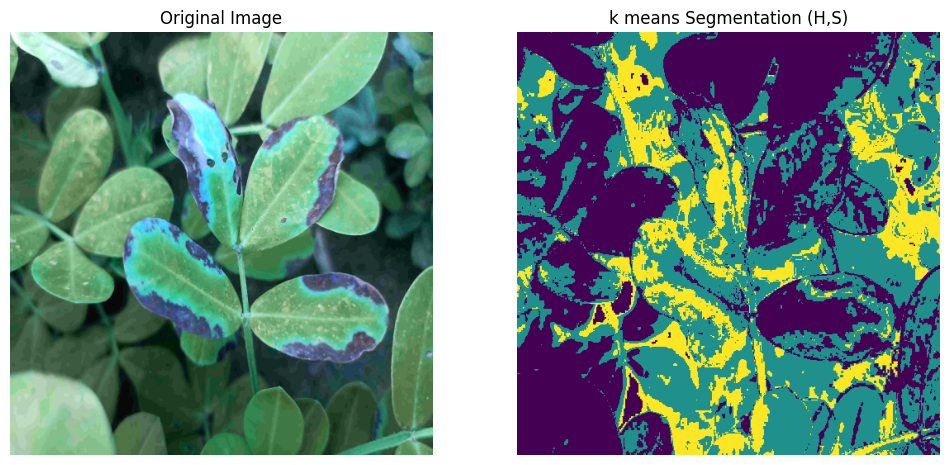

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

folder = "/content/drive/MyDrive/dataset/groundnut_leaf_data"

#image_name = os.listdir(folder)[0]
#path = os.path.join(folder, image_name)

img = img_resized
#img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

#extracting H and S channels
h, s, v = cv2.split(hsv)

#stack H and S as features
features = np.stack((h, s), axis=-1)

#reshape to (num_pixels, 2) for k mean clustering
pixels = features.reshape((-1,2))
pixels = np.float32(pixels)

#total number of clusters
K = 3

#K means criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,100,0.2)

#apply K means
_, labels, centers = cv2.kmeans(
    pixels,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

#convert labels back to image shape
labels = labels.reshape((img.shape[0], img.shape[1]))


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(labels, cmap="viridis")
plt.title("k means Segmentation (H,S)")
plt.axis("off")

plt.show()

# K means using LAB chromaticity without l

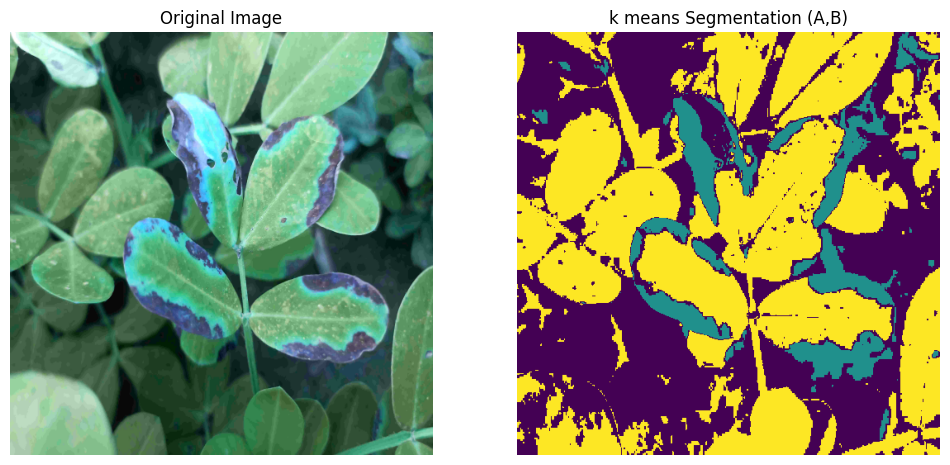

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

folder = "/content/drive/MyDrive/dataset/groundnut_leaf_data"

# image_name = os.listdir(folder)[0]
# path = os.path.join(folder, image_name)

img = img_resized
#img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

#split channels
l, a, b = cv2.split(lab)

#stack A and B channels
features = np.stack((a, b), axis=-1)

#reshape to (num_pixels, 2)
pixels = features.reshape((-1,2))
pixels = np.float32(pixels)

#number of clusters
K = 3

#K means termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

#K means
_, labels, centers = cv2.kmeans(
    pixels,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

#reshape labels back to image
segmented = labels.reshape((img.shape[0], img.shape[1]))


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap="viridis")
plt.title("k means Segmentation (A,B)")
plt.axis("off")

plt.show()